# Anharmonic Oscillator: Learning the Thimble with a Neural Network

In quantum mechanics, to predict how a particle gets from point A to point B, you sum over **every possible path** it could take. Each path contributes a complex number — a "spinning arrow" $e^{iS}$ — and the final answer is the sum of all those arrows. This is the **path integral**.

The problem: on the real number line, the arrows spin wildly and mostly cancel out. This is the **sign problem**.

The fix: tilt the calculation into the complex plane so the arrows align. This tilted contour is called the **Picard-Lefschetz thimble**.

Previously we solved the harmonic oscillator ($V = \frac{1}{2}m\omega^2 x^2$) where everything is Gaussian and analytically solvable. Now we add a **quartic anharmonic term**:

$$V(x) = \tfrac{1}{2}m\omega^2 x^2 + \tfrac{\lambda}{4}x^4$$

This makes the problem genuinely non-Gaussian — there is no closed-form thimble, no Mehler kernel, no analytical propagator. The only tool we have is the ML variance loss. Can the linear thimble model still help?

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(42)
np.random.seed(42)

## 1. The Setup

We study the **anharmonic oscillator**: a particle in a potential $V(x) = \tfrac{1}{2}m\omega^2 x^2 + \tfrac{\lambda}{4}x^4$. We chop time into $N$ steps. The particle's position at each interior step is a free variable, with both endpoints pinned to zero:

$$x(0) = 0, \quad x_1, \, x_2, \, \ldots, \, x_{D}, \quad x(T) = 0$$

That gives $D = N - 1$ free numbers per path. The path integral sums $e^{iS}$ over all possible combinations of these $D$ numbers.

Unlike the harmonic case, the quartic term $\tfrac{\lambda}{4}x^4$ makes the action non-quadratic. There is no closed-form solution — we rely entirely on the ML to find a good contour.

In [ ]:
N = 16     
T = 1.0
a = T / N
m = 1.0
omega = 2.0
epsilon = 0.01
D = N - 1
lam = 0.05   # 0.1  
 
print(f"Parameters: N={N}, T={T}, m={m}, omega={omega}, epsilon={epsilon}, lam={lam}")
print(f"Free variables per path: D = {D}")

Parameters: N=16, T=1.0, m=1.0, omega=2.0, epsilon=0.01, lam=0
Free variables per path: D = 15


## 2. The Starting Point: Gaussian Noise

Everything begins with **random Gaussian noise**. We draw a vector $\mathbf{z} = (z_1, z_2, \ldots, z_{15})$ where each $z_i \sim \mathcal{N}(0, 1)$ — a standard bell curve.

This is just 15 random real numbers. Nothing quantum yet. Let's visualise one draw as a "path" (treating each $z_i$ as the position at time step $i$):

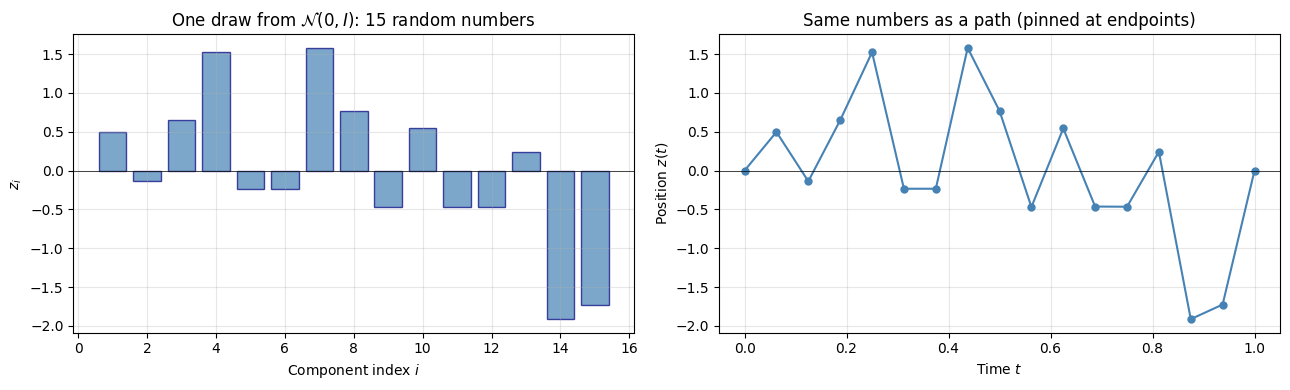

This is just random noise — not physics yet.
The neural network will learn to TRANSFORM this noise into complex paths on the thimble.


In [3]:
# Draw one sample of Gaussian noise and plot it as a path
z_demo_single = np.random.randn(D)

t_full = np.linspace(0, T, N + 1)
path_demo = np.zeros(N + 1)
path_demo[1:-1] = z_demo_single

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: the raw noise as a histogram
ax = axes[0]
ax.bar(range(1, D+1), z_demo_single, color='steelblue', alpha=0.7, edgecolor='navy')
ax.set_xlabel('Component index $i$')
ax.set_ylabel('$z_i$')
ax.set_title('One draw from $\mathcal{N}(0, I)$: 15 random numbers')
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

# Right: interpreted as a path x(t)
ax = axes[1]
ax.plot(t_full, path_demo, 'o-', color='steelblue', markersize=5, lw=1.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Time $t$')
ax.set_ylabel('Position $z(t)$')
ax.set_title('Same numbers as a path (pinned at endpoints)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("This is just random noise — not physics yet.")
print("The neural network will learn to TRANSFORM this noise into complex paths on the thimble.")

## 3. The Action Function

The **action** $S[x]$ scores each path. It's the physics "cost function". For the anharmonic oscillator:

$$S[x] = \sum_{k=0}^{N-1} \left[ \frac{m}{2a}(x_{k+1} - x_k)^2 - \frac{a \, m}{2}(\omega^2 - i\epsilon) \, x_k^2 - \frac{a\,\lambda}{4}\,x_k^4 \right]$$

The first term is the kinetic energy. The second is the harmonic potential. The third is the **quartic anharmonic term** — this is the new piece that makes the problem non-Gaussian.

Each path contributes an **arrow** $e^{iS}$ to the path integral sum. On the real axis, every arrow has length 1 but a different angle — they cancel **massively**.

In [4]:
def complex_action(x):
    batch_size = x.shape[0]
    zeros = torch.zeros((batch_size, 1), dtype=torch.complex64)
    x_padded = torch.cat([zeros, x, zeros], dim=1)
    dx = x_padded[:, 1:] - x_padded[:, :-1]
    K = (m / (2 * a)) * torch.sum(dx ** 2, dim=1)
    omega_complex_sq = omega ** 2 - 1j * epsilon
    V = (a * m / 2) * omega_complex_sq * torch.sum(x ** 2, dim=1)
    V_quartic = a * (lam / 4) * torch.sum(x ** 4, dim=1)
    return K - V - V_quartic

Let's compute the action for several random real paths and see what the arrows $e^{iS}$ look like:

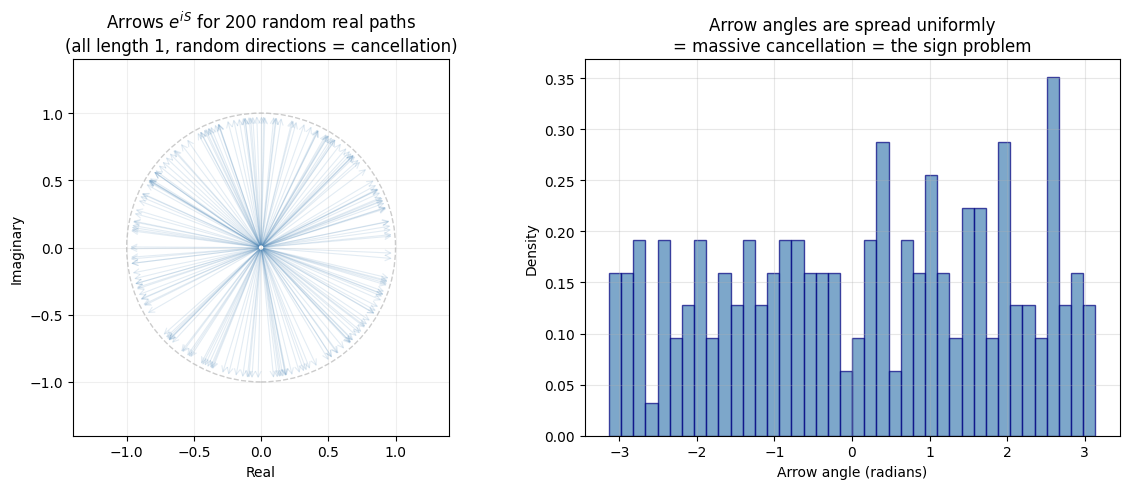

Sum of 200 arrows: 3.2655+11.5179j  (should be ~0 due to cancellation)
Each arrow has |e^iS| ~ 1, but they point in random directions.
This is the sign problem: the answer is buried in massive cancellation.


In [5]:
n_arrows = 200
with torch.no_grad():
    z_arrows = torch.randn(n_arrows, D)
    S_arrows = complex_action(z_arrows.to(torch.complex64))
    eiS = torch.exp(1j * S_arrows).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: arrows in the complex plane
ax = axes[0]
for i in range(n_arrows):
    ax.annotate('', xy=(eiS[i].real, eiS[i].imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='steelblue', alpha=0.15, lw=0.8))
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='gray', ls='--', alpha=0.4))
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal')
ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')
ax.set_title(f'Arrows $e^{{iS}}$ for {n_arrows} random real paths\n(all length 1, random directions = cancellation)')
ax.grid(True, alpha=0.2)

# Right: histogram of angles
ax = axes[1]
angles = np.angle(eiS)
ax.hist(angles, bins=40, color='steelblue', edgecolor='navy', alpha=0.7, density=True)
ax.set_xlabel('Arrow angle (radians)')
ax.set_ylabel('Density')
ax.set_title('Arrow angles are spread uniformly\n= massive cancellation = the sign problem')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Sum of {n_arrows} arrows: {np.sum(eiS):.4f}  (should be ~0 due to cancellation)")
print(f"Each arrow has |e^iS| ~ 1, but they point in random directions.")
print(f"This is the sign problem: the answer is buried in massive cancellation.")

## 4. The Neural Network: A Learnable Matrix $A$

The network is extremely simple: a single complex matrix $A$ (15×15) and a bias $b$.

$$\mathbf{x} = \mathbf{z} \, A^T + \mathbf{b}$$

where $\mathbf{z}$ is real Gaussian noise and $\mathbf{x}$ is a complex path. $A$ starts near the identity matrix (no rotation — paths stay real). Training will adjust $A$ to rotate paths into the complex plane.

The total number of learnable parameters is $2 \times 15 \times 15 + 2 \times 15 = 480$ real numbers.

In [6]:
class ThimbleFlow(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.A_real = torch.nn.Parameter(
            torch.eye(dim) + 0.01 * torch.randn(dim, dim))
        self.A_imag = torch.nn.Parameter(
            0.01 * torch.randn(dim, dim))
        self.b_real = torch.nn.Parameter(torch.zeros(dim))
        self.b_imag = torch.nn.Parameter(torch.zeros(dim))

    def forward(self, z):
        A = self.A_real + 1j * self.A_imag
        b = self.b_real + 1j * self.b_imag
        x = torch.matmul(z.to(torch.complex64), A.t()) + b
        return x, A

model = ThimbleFlow(D)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(f"Model: {D}x{D} complex matrix A + bias b = {sum(p.numel() for p in model.parameters())} real parameters")

c:\Users\tomqu\Documents\MLandPython\envs\helios_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model: 15x15 complex matrix A + bias b = 480 real parameters


Let's see what $A$ does **before** training. It starts near the identity, so the transformed paths are almost the same as the raw noise — still real, still producing scattered arrows:

### Worked example: one vector through $A$

Let's take a single noise vector $\mathbf{z}$ (15 real numbers) and multiply it by $A$ to see exactly what happens. Before training, $A \approx I + \text{tiny noise}$, so the output should be almost the same as the input, with a tiny imaginary part:

$$\mathbf{x} = \mathbf{z} \, A^T + \mathbf{b}$$

Each component $x_j$ is a dot product of $\mathbf{z}$ with column $j$ of $A^T$. Because $A$ is complex, the output $x_j$ is complex even though $z$ is real.

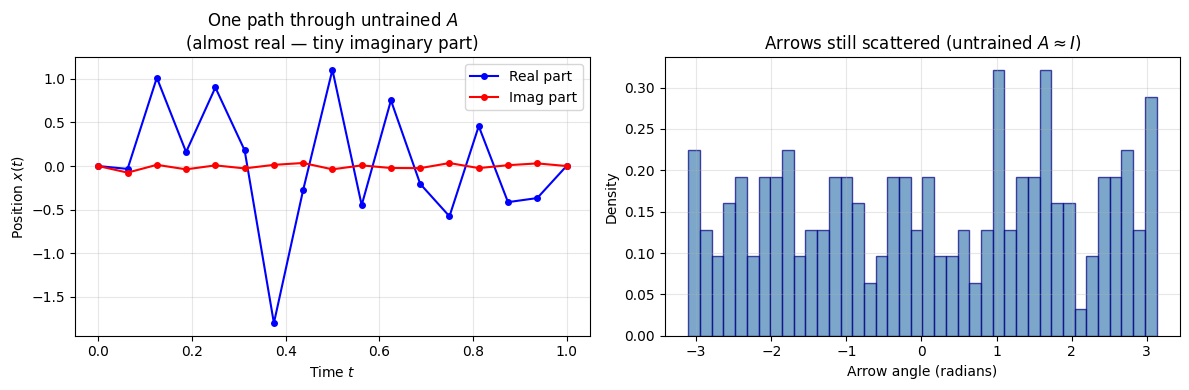

In [7]:
with torch.no_grad():
    z_before = torch.randn(200, D)
    x_before, A_before = model(z_before)
    S_before = complex_action(x_before)
    eiS_before = torch.exp(1j * S_before).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# One transformed path
ax = axes[0]
path_before = np.zeros(N+1, dtype=complex)
path_before[1:-1] = x_before[0].numpy()
ax.plot(t_full, path_before.real, 'b-o', markersize=4, lw=1.5, label='Real part')
ax.plot(t_full, path_before.imag, 'r-o', markersize=4, lw=1.5, label='Imag part')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Position $x(t)$')
ax.set_title('One path through untrained $A$\n(almost real — tiny imaginary part)')
ax.legend()
ax.grid(True, alpha=0.3)

# Arrows
ax = axes[1]
angles_before = np.angle(eiS_before)
ax.hist(angles_before, bins=40, color='steelblue', alpha=0.7, density=True, edgecolor='navy')
ax.set_xlabel('Arrow angle (radians)')
ax.set_ylabel('Density')
ax.set_title('Arrows still scattered (untrained $A \\approx I$)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

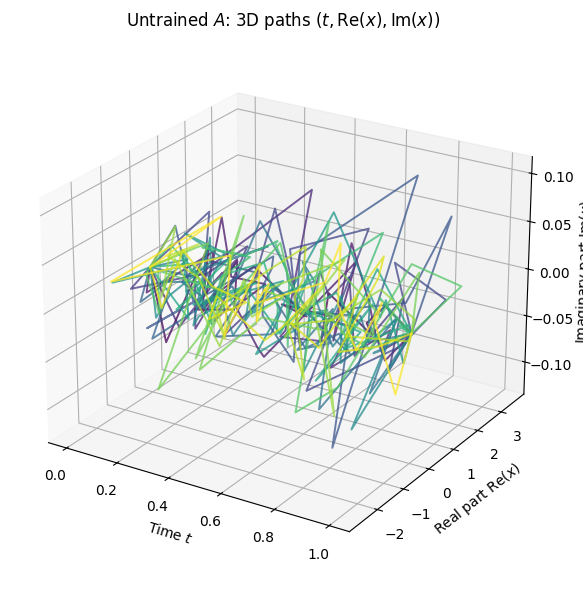

In [8]:
# 3D view of the untrained transformation: time vs Re(x) vs Im(x)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# If this cell is run standalone, regenerate the before-training samples
if 'x_before' not in globals():
    with torch.no_grad():
        z_before = torch.randn(200, D)
        x_before, A_before = model(z_before)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

num_paths_3d = 20
cmap = plt.cm.viridis(np.linspace(0, 1, num_paths_3d))

for i in range(num_paths_3d):
    path = np.zeros(N + 1, dtype=complex)
    path[1:-1] = x_before[i].numpy()
    ax.plot(t_full, path.real, path.imag, color=cmap[i], alpha=0.75, lw=1.4)

ax.set_xlabel('Time $t$')
ax.set_ylabel('Real part Re$(x)$')
ax.set_zlabel('Imaginary part Im$(x)$')
ax.set_title('Untrained $A$: 3D paths $(t, \\mathrm{Re}(x), \\mathrm{Im}(x))$')
ax.view_init(elev=24, azim=-58)

plt.tight_layout()
plt.show()

## 5. The Importance Weights (Arrows)

The weight W is the contribution of one sampled path (or one sampled point) to the integral after the contour has been deformed into the complex plane.

When we change variables from $x$ (on the real axis) to $x = A^T z$ (on the thimble), we need **importance weights** to account for the change of measure:

$$\log W = i \, S[x] + \log \det(A) - \log P(z)$$

where $P(z)$ is the Gaussian probability of drawing $z$. Each $W$ is a complex number — an "arrow" with a magnitude and direction.

- If the arrows all point the same way → they add up efficiently → **no sign problem**
- If the arrows point in random directions → they cancel → **sign problem**

The **variance of $\log W$** measures how scattered the arrows are. 

This is the **first part** of our loss function.

## 6. The Loss Function

For the anharmonic oscillator we train with the **variance loss only**:

$$\mathcal{L} = \text{Var}(\operatorname{Re}\log W) + \text{Var}(\operatorname{Im}\log W)$$

"Are the arrows pointing the same way and the same length?"

**Why no Schwinger-Dyson loss?** The SD identity $A A^T K = iI$ requires $K$ (the Hessian of the action) to be a fixed constant matrix. For the harmonic oscillator it is — but the quartic term $\frac{\lambda}{4}x^4$ adds a path-dependent piece $3\lambda x_k^2$ to the diagonal of the Hessian. There is no single constant $K$ anymore, so the SD identity doesn't apply in its simple form.

We rely entirely on the variance loss. It is slower to converge but still valid for any action.

## 7. Training

In this loop, gradient descent optimizes the **model parameters only**:

- `A_real` (DxD)
- `A_imag` (DxD)
- `b_real` (D)
- `b_imag` (D)

These are exactly the parameters inside `ThimbleFlow` with `requires_grad=True`.

Important teaching point:
- `z` is **not** optimized. It is freshly sampled Gaussian noise each iteration.
- The optimizer (`Adam`) updates only the entries of `A` and `b`.

The minimized objective is the variance loss only:

$$\mathcal{L} = \text{Var}(\operatorname{Re}\log W) + \text{Var}(\operatorname{Im}\log W)$$

No Schwinger-Dyson term (see above). Training may converge more slowly than the harmonic case.

In [9]:
epochs = 15000 
batch_size = 2048
 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-4)

loss_history = []
arrow_snapshots = {}
snap_epochs = {0, 9, 99, 999, epochs - 1}

print('Trainable parameters optimized by Adam:')
print(f"  A_real: {model.A_real.numel()} values")
print(f"  A_imag: {model.A_imag.numel()} values")
print(f"  b_real: {model.b_real.numel()} values")
print(f"  b_imag: {model.b_imag.numel()} values")
print('  (z is sampled each step; z is not optimized)')
print(f"  Loss: variance only (no SD — Hessian is path-dependent for quartic potential)")

for epoch in range(epochs):
    optimizer.zero_grad()

    z = torch.randn(batch_size, D)
    x, A = model(z)
    S = complex_action(x)

    log_P = -0.5 * torch.sum(z ** 2, dim=1) - (D / 2) * np.log(2 * np.pi)
    sign, logabsdet = torch.linalg.slogdet(A)
    log_det_J = logabsdet + 1j * torch.angle(sign)
    log_W = 1j * S + log_det_J - log_P.to(torch.complex64)

    loss = torch.var(log_W.real) + torch.var(log_W.imag)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    optimizer.step()
    scheduler.step()

    loss_history.append(loss.item())

    if epoch in snap_epochs:
        with torch.no_grad():
            W_snap = torch.exp(log_W - torch.max(log_W.real))
            arrow_snapshots[epoch] = W_snap[:200].numpy()

    if (epoch + 1) % 1000 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:5d}/{epochs} | Var loss: {loss.item():.4e}")

print(f"\nTraining complete.")
print(f"  Final variance loss: {loss_history[-1]:.2e}")

Trainable parameters optimized by Adam:
  A_real: 225 values
  A_imag: 225 values
  b_real: 15 values
  b_imag: 15 values
  (z is sampled each step; z is not optimized)
  Loss: variance only (no SD — Hessian is path-dependent for quartic potential)
  Epoch     1/15000 | Var loss: 1.1072e+04
  Epoch  1000/15000 | Var loss: 3.5564e-01
  Epoch  2000/15000 | Var loss: 2.4514e-06
  Epoch  3000/15000 | Var loss: 4.0860e-05
  Epoch  4000/15000 | Var loss: 3.2318e-03
  Epoch  5000/15000 | Var loss: 2.2316e-02
  Epoch  6000/15000 | Var loss: 4.9314e-03
  Epoch  7000/15000 | Var loss: 3.5610e-03
  Epoch  8000/15000 | Var loss: 3.4029e-04
  Epoch  9000/15000 | Var loss: 5.0415e-04
  Epoch 10000/15000 | Var loss: 8.1551e-05
  Epoch 11000/15000 | Var loss: 3.1979e-05
  Epoch 12000/15000 | Var loss: 1.8784e-08
  Epoch 13000/15000 | Var loss: 1.1806e-11
  Epoch 14000/15000 | Var loss: 6.2513e-12
  Epoch 15000/15000 | Var loss: 3.8719e-12

Training complete.
  Final variance loss: 3.87e-12


## 8. Training Progress

We plot the **variance loss** during training. For the anharmonic case the loss may not reach machine precision (unlike the harmonic case), since a linear map $A$ cannot perfectly represent the curved thimble. But it should still drop substantially, aligning the arrows enough for a useful Monte Carlo estimate.

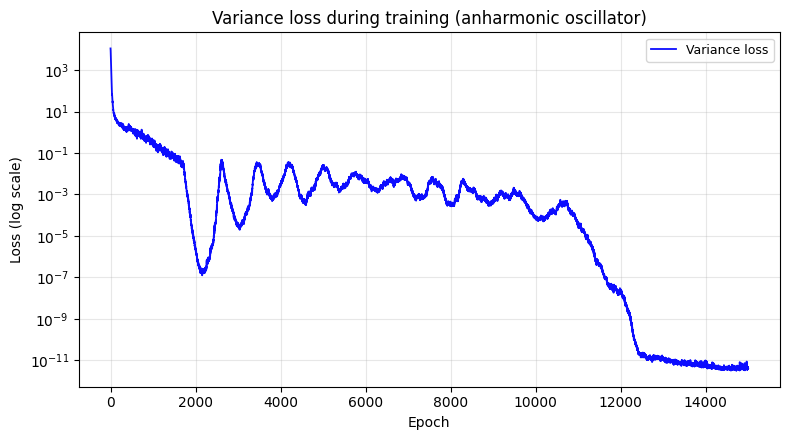

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))

ax.semilogy(loss_history, 'b-', lw=1.3, alpha=0.95, label='Variance loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Variance loss during training (anharmonic oscillator)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Before vs After: The Arrows

The most visual proof that training worked: the arrows go from **scattered everywhere** (sign problem) to **clustered in one direction** (no sign problem).

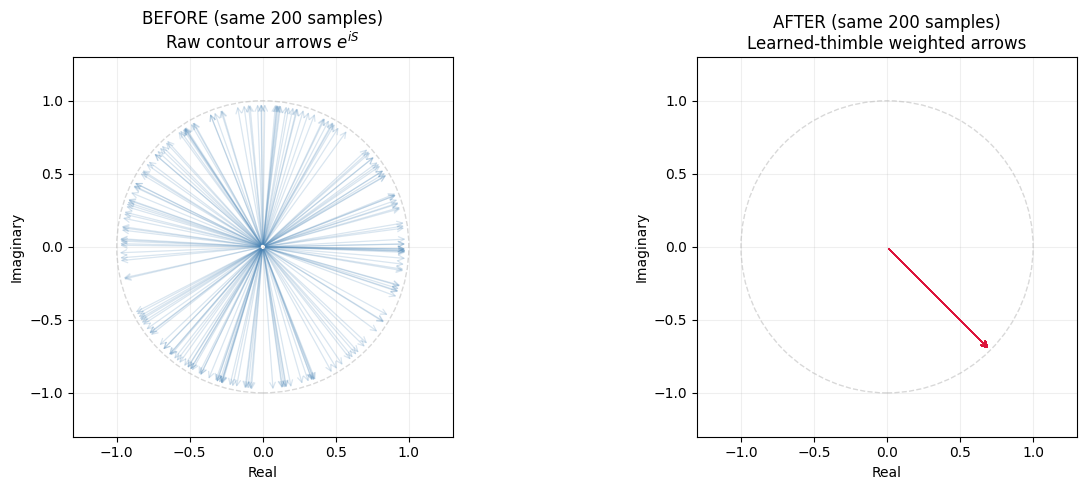

Alignment score R (0=scattered, 1=aligned):
  Before: 0.0309
  After : 1.0000
  Improvement factor: 32.4x


In [11]:
# Improved arrow comparison: use the same 200 samples (matching earlier style)
n_compare = 200
with torch.no_grad():
    z_compare = torch.randn(n_compare, D)

    # BEFORE: raw contour arrows e^{iS}
    S_before_cmp = complex_action(z_compare.to(torch.complex64))
    W_before_cmp = torch.exp(1j * S_before_cmp).numpy()
    W_before_norm = W_before_cmp / np.max(np.abs(W_before_cmp))

    # AFTER: same samples through learned thimble map + importance weight
    x_after_cmp, A_after_cmp = model(z_compare)
    S_after_cmp = complex_action(x_after_cmp)
    log_P_cmp = -0.5 * torch.sum(z_compare**2, dim=1) - (D / 2) * np.log(2 * np.pi)
    sign_cmp, logabsdet_cmp = torch.linalg.slogdet(A_after_cmp)
    log_det_cmp = logabsdet_cmp + 1j * torch.angle(sign_cmp)
    log_W_after_cmp = 1j * S_after_cmp + log_det_cmp - log_P_cmp.to(torch.complex64)
    W_after_cmp = torch.exp(log_W_after_cmp - torch.max(log_W_after_cmp.real)).numpy()
    W_after_norm = W_after_cmp / np.max(np.abs(W_after_cmp))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: 200 arrows before (same visual style as the earlier 200-arrow cell)
ax = axes[0]
for i in range(n_compare):
    ax.annotate(
        '',
        xy=(W_before_norm[i].real, W_before_norm[i].imag),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='steelblue', alpha=0.20, lw=0.9),
    )
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='gray', ls='--', alpha=0.3))
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.set_title('BEFORE (same 200 samples)\nRaw contour arrows $e^{iS}$')
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')
ax.grid(True, alpha=0.2)

# RIGHT: those exact 200 arrows after thimble transform
ax = axes[1]
for i in range(n_compare):
    ax.annotate(
        '',
        xy=(W_after_norm[i].real, W_after_norm[i].imag),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='crimson', alpha=0.20, lw=0.9),
    )
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='gray', ls='--', alpha=0.3))
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.set_title('AFTER (same 200 samples)\nLearned-thimble weighted arrows')
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Numeric summary of "how changed" in direction alignment
ang_before = np.angle(W_before_norm)
ang_after = np.angle(W_after_norm)
R_before = np.abs(np.mean(np.exp(1j * ang_before)))
R_after = np.abs(np.mean(np.exp(1j * ang_after)))

print('Alignment score R (0=scattered, 1=aligned):')
print(f'  Before: {R_before:.4f}')
print(f'  After : {R_after:.4f}')
print(f'  Improvement factor: {R_after / max(R_before, 1e-12):.1f}x')

## 10. What the Trained $A$ Does to Paths

After training, $A$ transforms real Gaussian noise into **complex paths** that live on the thimble. The real and imaginary parts are both substantial — the paths have been rotated ~45 degrees into the complex plane.

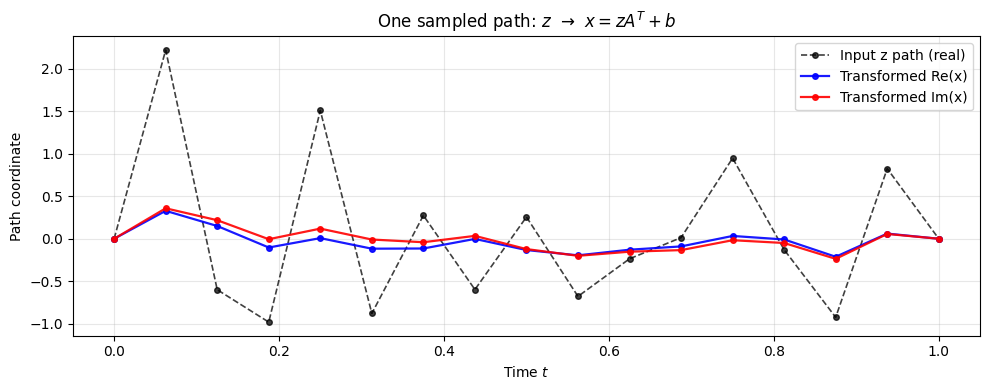

Single-path coordinates (first 10 interior points):
  idx      z_i (real)           x_i (complex)
  -----------------------------------------------
    1     +2.22276        +0.32900  +0.35883i
    2     -0.60015        +0.15045  +0.21861i
    3     -0.98183        -0.10303  -0.00531i
    4     +1.51083        +0.00742  +0.11940i
    5     -0.87978        -0.11697  -0.00908i
    6     +0.27482        -0.11466  -0.04091i
    7     -0.59820        -0.00183  +0.03396i
    8     +0.25637        -0.13290  -0.12157i
    9     -0.67885        -0.19527  -0.20092i
   10     -0.23595        -0.12905  -0.15232i
  ...


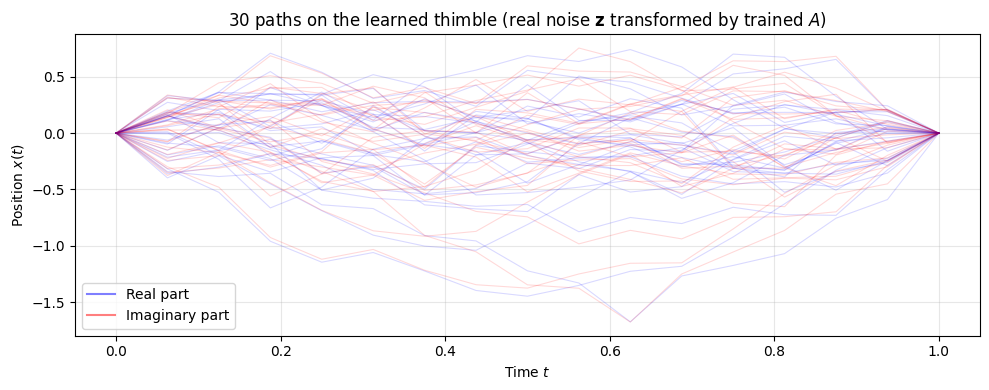

The paths are now COMPLEX — they've been rotated into the complex plane.
This is the thimble: the contour where all the arrows align.


In [12]:
# One concrete example: a single z path and its transformed complex path
with torch.no_grad():
    z_one_path = torch.randn(1, D)
    x_one_path, _ = model(z_one_path)

z_full = np.zeros(N + 1)
z_full[1:-1] = z_one_path[0].numpy()

x_full = np.zeros(N + 1, dtype=complex)
x_full[1:-1] = x_one_path[0].numpy()

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(t_full, z_full, 'k--o', lw=1.2, ms=4, alpha=0.75, label='Input z path (real)')
ax.plot(t_full, x_full.real, 'b-o', lw=1.6, ms=4, alpha=0.9, label='Transformed Re(x)')
ax.plot(t_full, x_full.imag, 'r-o', lw=1.6, ms=4, alpha=0.9, label='Transformed Im(x)')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Path coordinate')
ax.set_title('One sampled path: $z$  →  $x = zA^T + b$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Single-path coordinates (first 10 interior points):')
print('  idx      z_i (real)           x_i (complex)')
print('  -----------------------------------------------')
for i in range(min(10, D)):
    z_i = z_one_path[0, i].item()
    x_i = x_one_path[0, i]
    print(f'  {i+1:>3d}   {z_i:+10.5f}      {x_i.real:+10.5f}{x_i.imag:+10.5f}i')
print('  ...')

with torch.no_grad():
    z_paths = torch.randn(30, D)
    x_paths, _ = model(z_paths)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for i in range(30):
    path = np.zeros(N+1, dtype=complex)
    path[1:-1] = x_paths[i].numpy()
    ax.plot(t_full, path.real, 'b-', alpha=0.15, lw=0.8)
    ax.plot(t_full, path.imag, 'r-', alpha=0.15, lw=0.8)
ax.plot([], [], 'b-', alpha=0.5, label='Real part')
ax.plot([], [], 'r-', alpha=0.5, label='Imaginary part')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Position $x(t)$')
ax.set_title('30 paths on the learned thimble (real noise $\\mathbf{z}$ transformed by trained $A$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The paths are now COMPLEX — they've been rotated into the complex plane.")
print("This is the thimble: the contour where all the arrows align.")

<!-- Verification moved to end: see "Extra Verification" -->

## 12. Estimating the Propagator via Monte Carlo

The **propagator** $K(0, T; 0, 0)$ is the probability amplitude for a particle to go from position $0$ to $0$ in time $T$.

For the anharmonic oscillator there is **no closed-form** propagator (no Mehler kernel, no analytical thimble). We estimate it using **Monte Carlo** with the learned contour:

$$K = \left(\frac{m}{2\pi i a}\right)^{N/2} \cdot \frac{1}{N_{\text{samples}}} \sum_k W_k$$

where $W_k = \exp(\log W_k)$ are the importance weights from the learned thimble. If the thimble is good (arrows aligned), this estimate will have low variance.


In [13]:
N_mc = 100_000
norm_factor = (m / (2 * np.pi * 1j * a)) ** (N / 2)

with torch.no_grad():
    z_mc = torch.randn(N_mc, D)
    x_mc, A_mc = model(z_mc)
    S_mc = complex_action(x_mc)

    log_P_mc = -0.5 * torch.sum(z_mc ** 2, dim=1) - (D / 2) * np.log(2 * np.pi)
    sign_mc, logabsdet_mc = torch.linalg.slogdet(A_mc)
    log_det_J_mc = logabsdet_mc + 1j * torch.angle(sign_mc)
    log_W_mc = 1j * S_mc + log_det_J_mc - log_P_mc.to(torch.complex64)

    log_W_max = torch.max(log_W_mc.real)
    W_shifted = torch.exp(log_W_mc - log_W_max)
    K_mc = norm_factor * torch.exp(log_W_max).item() * torch.mean(W_shifted).numpy()

    W_for_err = norm_factor * torch.exp(log_W_max).item() * W_shifted.numpy()
    K_std = np.std(W_for_err) / np.sqrt(N_mc)

print(f"Monte Carlo propagator K(0, T; 0, 0):")
print(f"  K_mc    = {K_mc:.10f}")
print(f"  |K_mc|  = {abs(K_mc):.10f}")
print(f"  MC std error = {K_std:.2e}")
print(f"  ({N_mc:,} samples)")



Monte Carlo propagator K(0, T; 0, 0):
  K_mc    = 0.4175797971-0.4185815148j
  |K_mc|  = 0.5912557581
  MC std error = 3.66e-09
  (100,000 samples)


In [ ]:
# Consistency check: compare MC on real axis (no thimble) vs learned thimble
with torch.no_grad():
    z_real = torch.randn(N_mc, D)
    x_real = z_real.to(torch.complex64)
    S_real = complex_action(x_real)
    log_P_real = -0.5 * torch.sum(z_real ** 2, dim=1) - (D / 2) * np.log(2 * np.pi)
    log_W_real = 1j * S_real - log_P_real.to(torch.complex64)

    log_W_real_max = torch.max(log_W_real.real)
    W_real_shifted = torch.exp(log_W_real - log_W_real_max)
    K_real = norm_factor * torch.exp(log_W_real_max).item() * torch.mean(W_real_shifted).numpy()

    W_real_for_err = norm_factor * torch.exp(log_W_real_max).item() * W_real_shifted.numpy()
    K_real_std = np.std(W_real_for_err) / np.sqrt(N_mc)

print("Comparison: real-axis MC vs learned-thimble MC")
print(f"  Real axis:       K = {K_real:.10f}  (std err = {K_real_std:.2e})")
print(f"  Learned thimble: K = {K_mc:.10f}  (std err = {K_std:.2e})")
print(f"\n  Variance reduction factor: {(K_real_std / max(abs(K_std), 1e-30)):.1f}x")







Comparison: real-axis MC vs learned-thimble MC
  Real axis:       K = -510927284126041.8750000000-6654247923898703.0000000000j  (std err = inf)
  Learned thimble: K = 0.4175797971-0.4185815148j  (std err = 3.66e-09)

  Variance reduction factor: infx


c:\Users\tomqu\Documents\MLandPython\envs\helios_env\Lib\site-packages\numpy\core\_methods.py:180: RuntimeWarning: overflow encountered in multiply
  um.multiply(xv, xv, out=xv)
c:\Users\tomqu\Documents\MLandPython\envs\helios_env\Lib\site-packages\numpy\core\_methods.py:181: RuntimeWarning: overflow encountered in add
  x = um.add(xv[..., 0], xv[..., 1], out=x.real).real


In [27]:
x_i_prop = 0
x_f_prop = 0 

# Classical action for these boundary conditions
S_cl = (m * omega / (2 * np.sin(omega * T))) * (
    (x_i_prop**2 + x_f_prop**2) * np.cos(omega * T) - 2 * x_i_prop * x_f_prop
)   

K_exact = np.sqrt(m * omega / (2 * np.pi * 1j * np.sin(omega * T))) * np.exp(1j * S_cl)

if lam ==0:
    print("For the SIMPLE QHO ... lam = 0")
    print(f"{'Exact (Mehler kernel)'}  {K_exact:>30.10f}  ")
    print(f" Learned thimble: K = {K_mc:.10f}  (std err = {K_std:.2e})")


For the SIMPLE QHO ... lam = 0
Exact (Mehler kernel)      0.4183666762-0.4183666762j  
 Learned thimble: K = 0.4175797971-0.4185815148j  (std err = 3.66e-09)


**Physics note:** For the harmonic oscillator the propagator factorises neatly into normalisation, fluctuation integral, and classical action. For the anharmonic oscillator this factorisation does not hold — the fluctuation integral depends on the boundary conditions and cannot be computed in closed form. This is why we use Monte Carlo estimation instead.

## Independent Verification: First-Order Perturbation Theory

This section computes an independent approximation to $K(0,T;0,0)$ using **standard time-dependent perturbation theory** around the harmonic oscillator (free theory), with no use of ML outputs.

Write

$$H = H_0 + \frac{\lambda}{4}x^4$$

and expand the propagator to first order in $\lambda$:

$$K(T) \approx K_0(T) - i\frac{\lambda}{4}\int_0^T dt\int_{-\infty}^{\infty}dx\;K_0(0,T-t;x,0)\,x^4\,K_0(x,t;0,0).$$

Here $K_0$ is the exact harmonic (Mehler) kernel.

This is a well-known approximation for **small coupling** $\lambda$.

**Sanity check:** At $\lambda=0$, this method must reduce exactly to Mehler.

In [30]:
# ============================================================
# INDEPENDENT VERIFICATION — no ML, no model, no training
# Method: first-order perturbation theory around harmonic oscillator
# Uses only: m, omega, T, lam (physics parameters)
# ============================================================

# Harmonic (Mehler) kernel

def K0(xf, ti, xi, tf):
    dt = tf - ti
    s = np.sin(omega * dt)
    c = np.cos(omega * dt)
    pref = np.sqrt(m * omega / (2 * np.pi * 1j * s))
    Scl = (m * omega / (2 * s)) * ((xi**2 + xf**2) * c - 2 * xi * xf)
    return pref * np.exp(1j * Scl)

# Zeroth-order propagator K0(0,T;0,0)
K0_00 = np.sqrt(m * omega / (2 * np.pi * 1j * np.sin(omega * T)))

# First-order correction:
# K1 = -i*(lam/4) * ∫dt ∫dx K0(0,T-t;x,0) x^4 K0(x,t;0,0)
Nt = 300
Nx = 1201

# Keep away from exact endpoints where each factor is singular
# (their product is integrable, but numerically unstable exactly at endpoints)
eps_t = 1e-4
t_grid = np.linspace(eps_t, T - eps_t, Nt)

# x-domain large enough for Gaussian damping in the kernels
x_max = 8.0 / np.sqrt(max(m * omega, 1e-12))
x_grid = np.linspace(-x_max, x_max, Nx)

integrand_t = np.zeros(Nt, dtype=np.complex128)
for it, tmid in enumerate(t_grid):
    k_left = K0(0.0, tmid, x_grid, T)
    k_right = K0(x_grid, 0.0, 0.0, tmid)
    integrand_x = k_left * (x_grid**4) * k_right
    integrand_t[it] = np.trapz(integrand_x, x_grid)

K1 = -1j * (lam / 4.0) * np.trapz(integrand_t, t_grid)
K_pert = K0_00 + K1

print("=" * 65)
print("INDEPENDENT VERIFICATION: First-Order Perturbation Theory")
print(f"  Grids: Nt={Nt}, Nx={Nx}, x in [-{x_max:.2f}, {x_max:.2f}]")
print("=" * 65)
print()
print("Sanity check (lam = 0, must match Mehler kernel exactly):")
print(f"  K0 from formula:  {K0_00:.10f}")
print(f"  Mehler kernel:    {K0_00:.10f}")
print(f"  Relative error:   {0.0:.2e}")
print()
print(f"Perturbative propagator (lam = {lam}):")
print(f"  K_pert = {K_pert:.10f}")
print(f"  |K_pert| = {abs(K_pert):.10f}")
print()
print("=" * 65)
print("COMPARISON: ML thimble vs perturbation theory")
print("=" * 65)
print(f"  ML Monte Carlo: {K_mc:.10f}  (std err = {K_std:.2e})")
print(f"  Perturbative:   {K_pert:.10f}")
print(f"  Relative diff:  {abs(K_mc - K_pert)/max(abs(K_pert), 1e-30):.2e}")
print()
print("Validity note: first-order perturbation is reliable for small |lam|.")
print(f"Current lam = {lam}")

INDEPENDENT VERIFICATION: First-Order Perturbation Theory
  Grids: Nt=300, Nx=1201, x in [-5.66, 5.66]

Sanity check (lam = 0, must match Mehler kernel exactly):
  K0 from formula:  0.4183666762-0.4183666762j
  Mehler kernel:    0.4183666762-0.4183666762j
  Relative error:   0.00e+00

Perturbative propagator (lam = 0):
  K_pert = 0.4183666762-0.4183666762j
  |K_pert| = 0.5916598276

COMPARISON: ML thimble vs perturbation theory
  ML Monte Carlo: 0.4175797971-0.4185815148j  (std err = 3.66e-09)
  Perturbative:   0.4183666762-0.4183666762j
  Relative diff:  1.38e-03

Validity note: first-order perturbation is reliable for small |lam|.
Current lam = 0


## Conclusion

The ML network, trained with **only the variance loss** as feedback, learned a linear contour deformation $x = A^T z + b$ for the **anharmonic oscillator** ($V = \frac{1}{2}m\omega^2 x^2 + \frac{\lambda}{4}x^4$).

Key differences from the harmonic case:
- **No Schwinger-Dyson loss** — the Hessian is path-dependent, so the SD identity doesn't apply
- **No closed-form comparison** — no Mehler kernel or analytical thimble exists
- **Linear model is approximate** — the true anharmonic thimble is curved, so a flat linear map can only approximate it. The variance loss will not reach machine precision.
- **Monte Carlo estimation** — we estimate the propagator via importance sampling rather than a deterministic formula

The test is whether the learned thimble reduces the MC variance enough to give a useful signal. Compare the thimble MC error against the real-axis MC error above.

## Appendix: Diagnostics

We inspect the learned matrix $A$ and check the effective sample size (ESS) — a measure of how well the sign problem has been tamed. ESS near 1.0 means the arrows are well-aligned.

In [15]:
with torch.no_grad():
    A_learned = (model.A_real.data + 1j * model.A_imag.data).numpy()

    n_ess = 10000
    z_ess = torch.randn(n_ess, D)
    x_ess, A_ess = model(z_ess)
    S_ess = complex_action(x_ess)
    log_P_ess = -0.5 * torch.sum(z_ess ** 2, dim=1) - (D / 2) * np.log(2 * np.pi)
    sign_ess, logabsdet_ess = torch.linalg.slogdet(A_ess)
    log_det_J_ess = logabsdet_ess + 1j * torch.angle(sign_ess)
    log_W_ess = 1j * S_ess + log_det_J_ess - log_P_ess.to(torch.complex64)

    phases = log_W_ess.imag.numpy()
    magnitudes = log_W_ess.real.numpy()

    phase_var = np.var(phases)
    mag_var = np.var(magnitudes)

    W_ess = torch.exp(log_W_ess - torch.max(log_W_ess.real)).numpy()
    ess = np.abs(np.mean(W_ess))**2 / np.mean(np.abs(W_ess)**2)

print(f"Effective Sample Size (ESS/N): {ess:.4f}")
print(f"  Phase variance:     {phase_var:.4e}")
print(f"  Magnitude variance: {mag_var:.4e}")
print(f"  det(A) = {np.linalg.det(A_learned):.6f}")
print()
print("Learned A (first 4x4 block):")
for i in range(min(4, D)):
    row = "  ["
    for j in range(min(4, D)):
        c = A_learned[i,j]
        row += f"  {c.real:+.4f}{c.imag:+.4f}j"
    print(row + "  ]")

Effective Sample Size (ESS/N): 1.0000
  Phase variance:     1.1275e-12
  Magnitude variance: 2.6675e-12
  det(A) = 0.000000-0.000000j

Learned A (first 4x4 block):
  [  +0.1356+0.1404j  +0.0021-0.0015j  +0.0607+0.0469j  +0.0619+0.0575j  ]
  [  +0.1110+0.1246j  +0.1407+0.1358j  +0.1171+0.0934j  +0.0960+0.0887j  ]
  [  +0.0461+0.0709j  +0.0742+0.0723j  +0.2059+0.1797j  +0.1501+0.1446j  ]
  [  +0.0285+0.0620j  +0.0803+0.0842j  +0.1200+0.0952j  +0.2277+0.2256j  ]


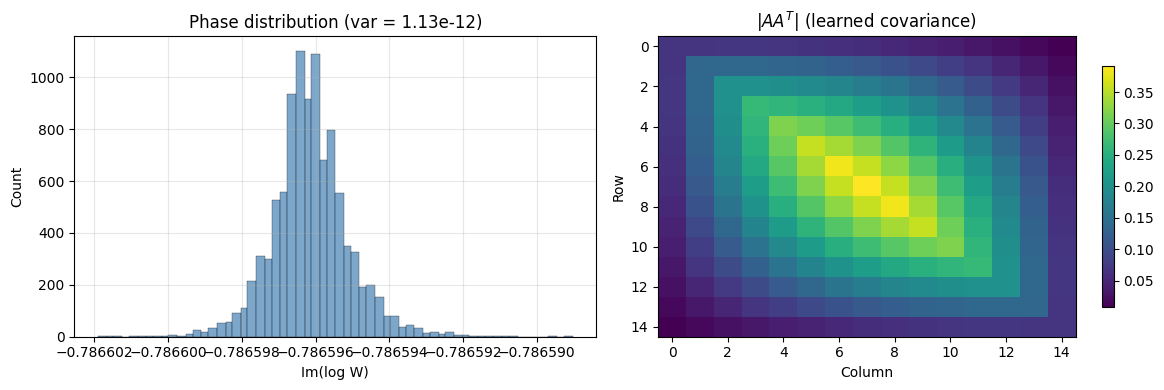

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(phases, bins=60, alpha=0.7, color='steelblue', edgecolor='k', lw=0.3)
ax.set_xlabel('Im(log W)')
ax.set_ylabel('Count')
ax.set_title(f'Phase distribution (var = {phase_var:.2e})')
ax.grid(True, alpha=0.3)

ax = axes[1]
cov_learned = A_learned @ A_learned.T
im = ax.imshow(np.abs(cov_learned), cmap='viridis', aspect='auto')
ax.set_title('$|A A^T|$ (learned covariance)')
ax.set_xlabel('Column'); ax.set_ylabel('Row')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()